In [381]:
%pip install ucimlrepo


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [382]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [383]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [384]:
print("Features shape :", X.shape)
print("Target shape   :", y.shape)

print("\nTotal rows      :", len(X))
print("Number features :", X.shape[1])

Features shape : (48842, 14)
Target shape   : (48842, 1)

Total rows      : 48842
Number features : 14


In [385]:
display(X.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [386]:
display(y.head())

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [387]:
print("Feature columns:\n")

for i, column in enumerate(X.columns, start=1):
    print(f"{i:2}. {column}")

Feature columns:

 1. age
 2. workclass
 3. fnlwgt
 4. education
 5. education-num
 6. marital-status
 7. occupation
 8. relationship
 9. race
10. sex
11. capital-gain
12. capital-loss
13. hours-per-week
14. native-country


In [388]:
print("Target column(s):")
print(y.columns.tolist())

print("\nTarget values:")
print(y.iloc[:, 0].unique())

Target column(s):
['income']

Target values:
['<=50K' '>50K' '<=50K.' '>50K.']


In [389]:
df = pd.concat(
    [X, y],
    axis=1
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [390]:
target_column = y.columns[0]

print("Original target:", target_column)

df = df.rename(
    columns={
        target_column: "income"
    }
)

print(df.columns.tolist())

Original target: income
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [391]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [392]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [393]:
display(
    df.describe(include="object").T
)

,count,unique,top,freq
workclass,47879,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,47876,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,48568,42,United-States,43832
income,48842,4,<=50K,24720


In [394]:
dtype_report = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [
        df[col].nunique(dropna=False)
        for col in df.columns
    ]
})

display(dtype_report)

,feature,dtype,unique_values
0,age,int64,74
1,workclass,object,10
2,fnlwgt,int64,28523
3,education,object,16
4,education-num,int64,16
5,marital-status,object,7
6,occupation,object,16
7,relationship,object,6
8,race,object,5
9,sex,object,2


In [395]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    )
})

missing_report = (
    missing_report
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missing_report)

,missing_count,missing_percentage
occupation,966,1.977806
workclass,963,1.971664
native-country,274,0.560993
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
age,0,0.000000
marital-status,0,0.000000
relationship,0,0.000000
sex,0,0.000000


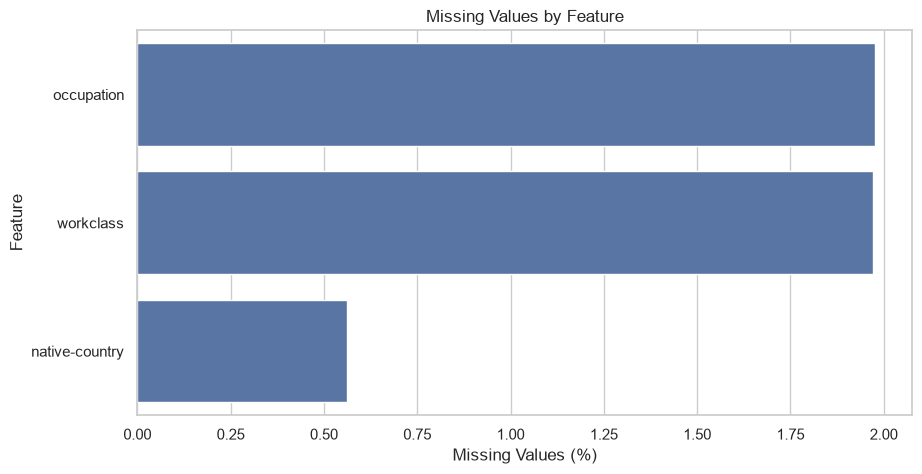

In [396]:
missing_plot = (
    missing_report[
        missing_report["missing_count"] > 0
    ]
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_plot,
    x="missing_percentage",
    y="feature"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.show()

In [397]:
duplicate_count = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicate_count:,}"
)

Duplicate rows: 29


In [398]:
print(
    df["income"]
    .value_counts(dropna=False)
)

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64


In [399]:
df["income"] = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print(
    df["income"].value_counts()
)

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [400]:
income_mapping = {
    "<=50K": 0,
    ">50K": 1
}

df["income_binary"] = (
    df["income"]
    .map(income_mapping)
)

print(
    df["income_binary"].value_counts()
)

income_binary
0    37155
1    11687
Name: count, dtype: int64


In [401]:
print(
    "Unmapped target values:",
    df["income_binary"].isna().sum()
)

Unmapped target values: 0


In [402]:
target_distribution = pd.DataFrame({
    "count": df["income_binary"].value_counts(),
    "percentage": (
        df["income_binary"]
        .value_counts(normalize=True)
        .mul(100)
    )
})

target_distribution.index = [
    "<=50K",
    ">50K"
]

display(target_distribution)

,count,percentage
<=50K,37155,76.071823
>50K,11687,23.928177


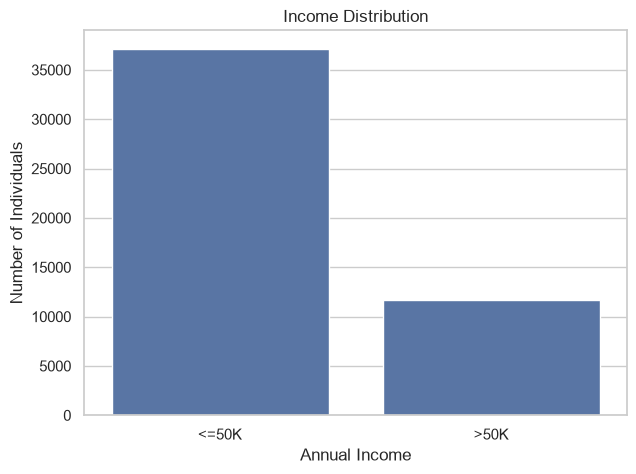

In [403]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="income"
)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Individuals")

plt.show()

In [404]:
numeric_columns = (
    df
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income_binary']


In [405]:
categorical_columns = (
    df
    .select_dtypes(
        include="object"
    )
    .columns
    .tolist()
)

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


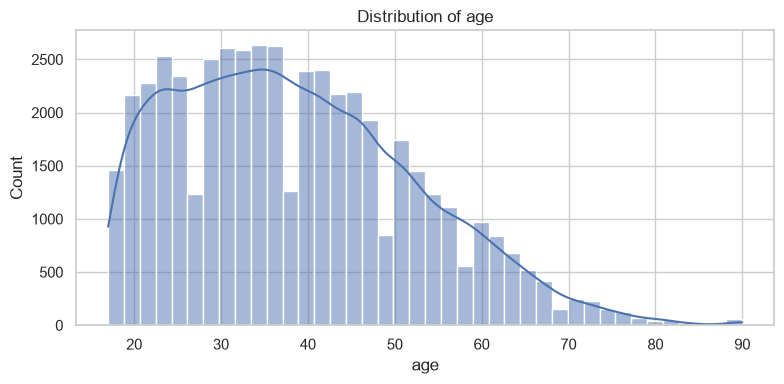

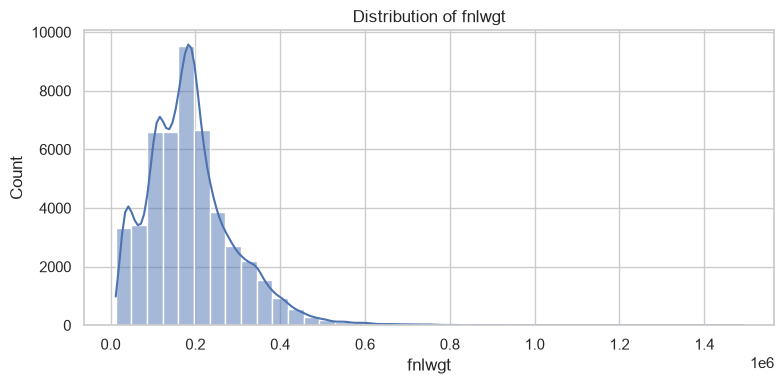

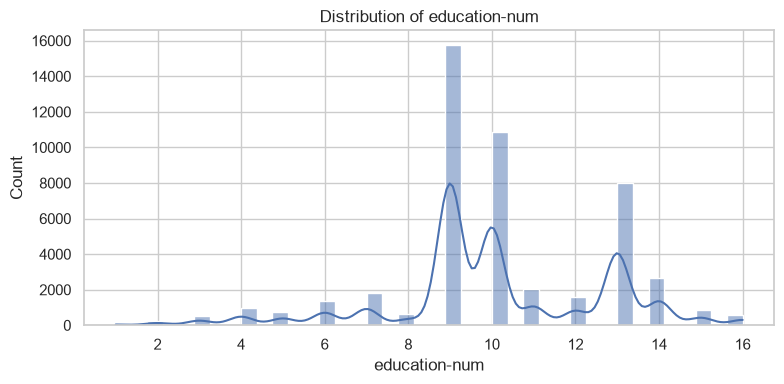

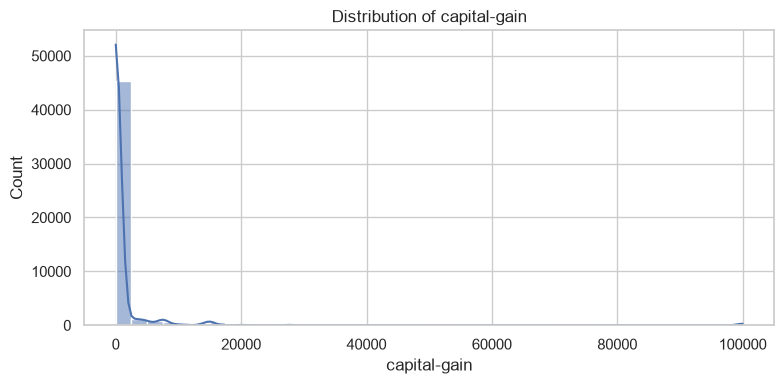

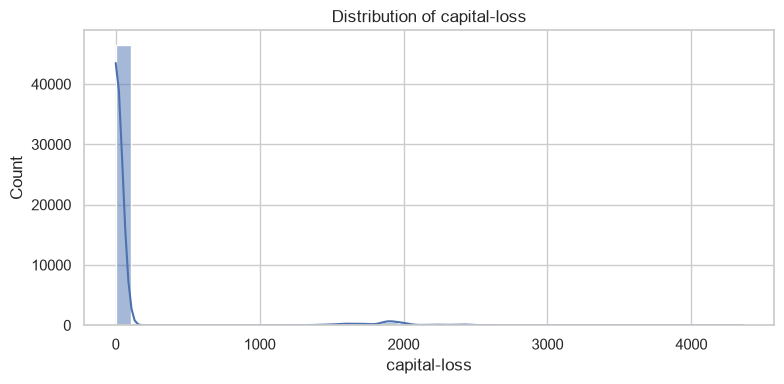

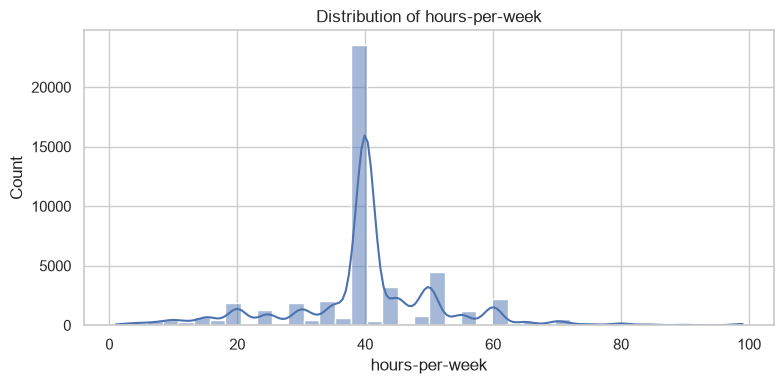

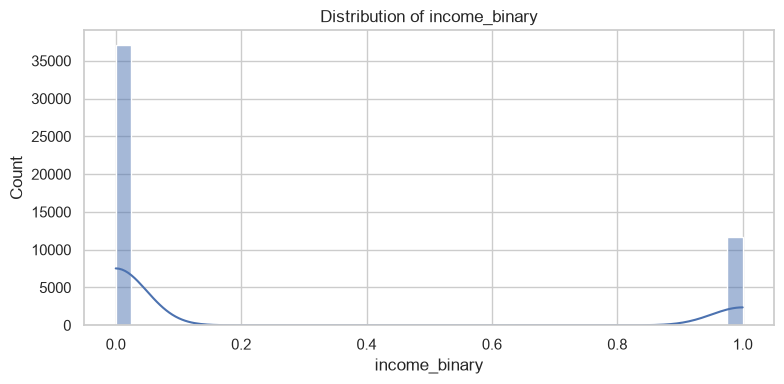

In [406]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=40
    )

    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

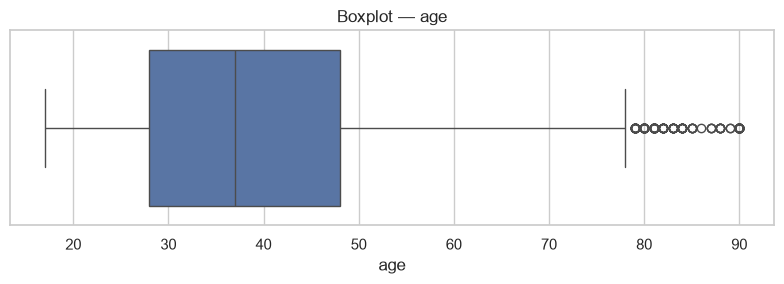

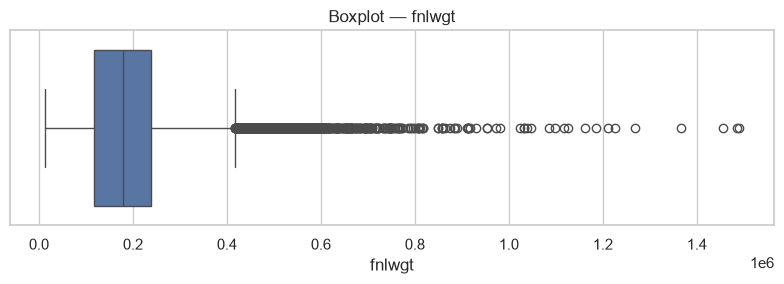

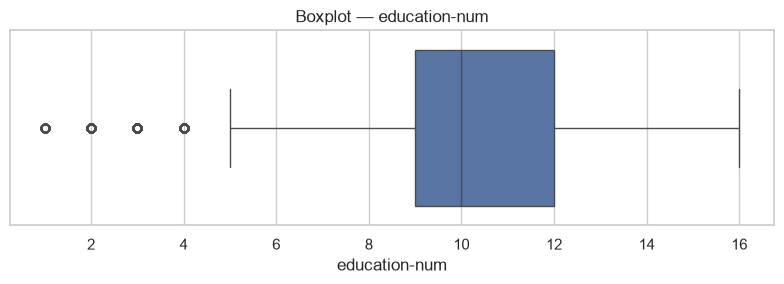

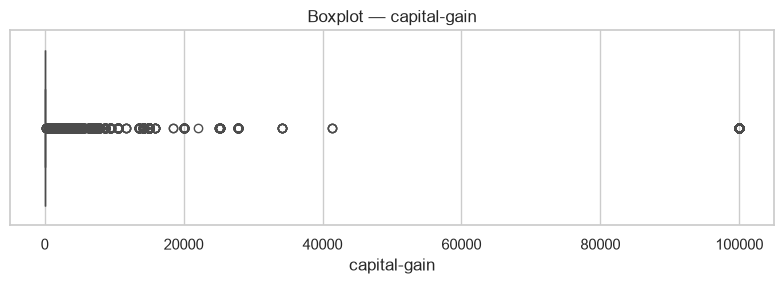

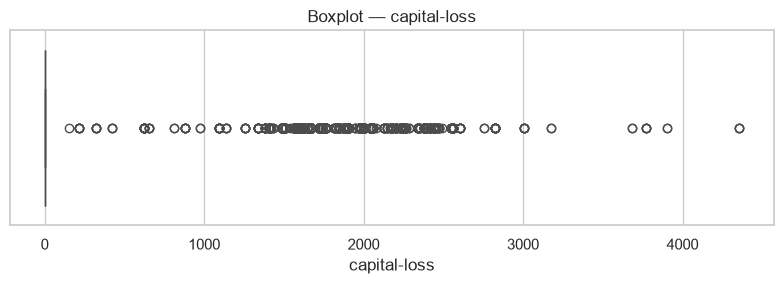

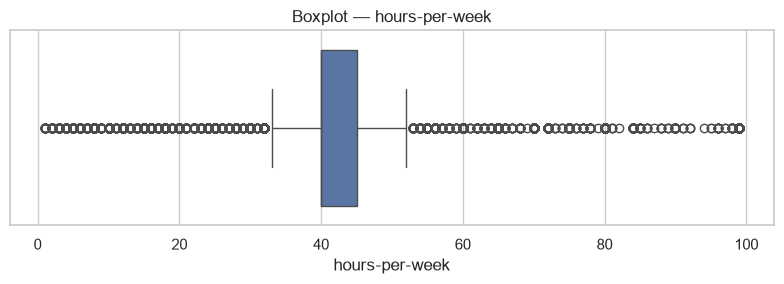

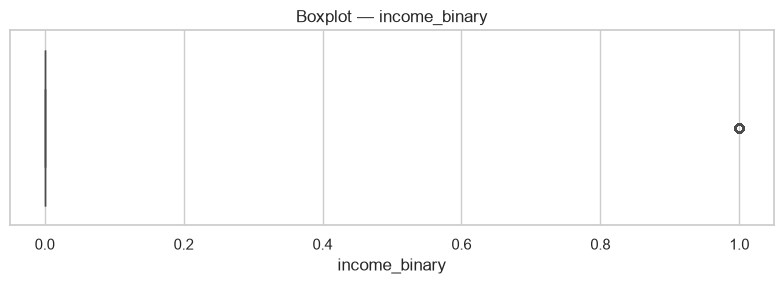

In [407]:
for column in numeric_columns:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot — {column}")

    plt.tight_layout()
    plt.show()

In [408]:
for column in categorical_columns:

    print(f"\n{'=' * 60}")
    print(column)
    print(f"{'=' * 60}")

    display(
        df[column]
        .value_counts(dropna=False)
        .to_frame("count")
    )


workclass


,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
?,1836
Self-emp-inc,1695
Federal-gov,1432
NaN,963
Without-pay,21



education


,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955



marital-status


...

,count
sex,
Male,32650
Female,16192



native-country


,count
native-country,
United-States,43832
Mexico,951
?,583
Philippines,295
NaN,274
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155



income


,count
income,
<=50K,37155
>50K,11687


In [409]:
sex_distribution = (
    df["sex"]
    .value_counts(dropna=False)
    .to_frame("count")
)

sex_distribution["percentage"] = (
    sex_distribution["count"]
    / len(df)
    * 100
)

display(sex_distribution)

,count,percentage
sex,,
Male,32650,66.848204
Female,16192,33.151796


In [410]:
race_distribution = (
    df["race"]
    .value_counts(dropna=False)
    .to_frame("count")
)

race_distribution["percentage"] = (
    race_distribution["count"]
    / len(df)
    * 100
)

display(race_distribution)

,count,percentage
race,,
White,41762,85.504279
Black,4685,9.592154
Asian-Pac-Islander,1519,3.110028
Amer-Indian-Eskimo,470,0.962287
Other,406,0.831252


In [411]:
display(
    df["age"].describe()
)

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

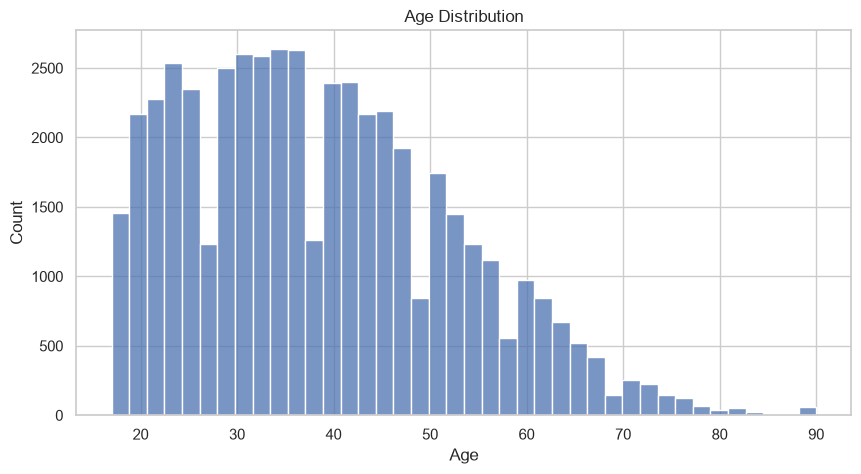

In [412]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age",
    bins=40
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [413]:
def create_age_group(age):

    if age < 25:
        return "18-24"

    elif age < 35:
        return "25-34"

    elif age < 45:
        return "35-44"

    elif age < 55:
        return "45-54"

    elif age < 65:
        return "55-64"

    else:
        return "65+"

In [414]:
df["age_group"] = (
    df["age"]
    .apply(create_age_group)
)

In [415]:
display(
    df["age_group"]
    .value_counts()
    .sort_index()
)

age_group
18-24     8432
25-34    12577
35-44    12193
45-54     8771
55-64     4782
65+       2087
Name: count, dtype: int64

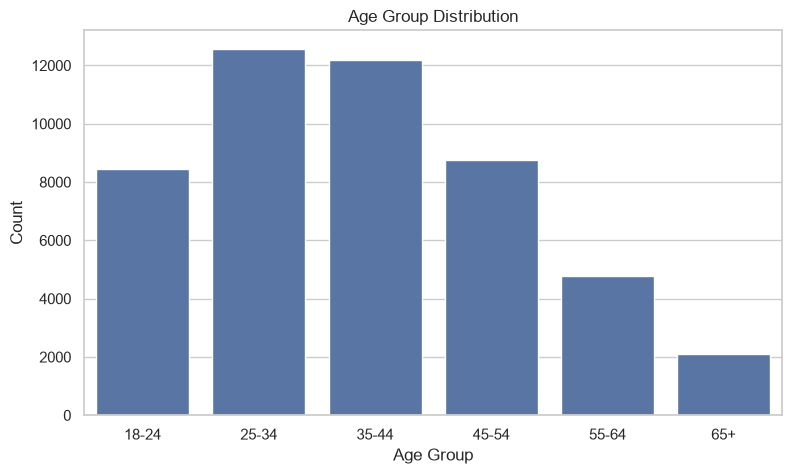

In [416]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="age_group",
    order=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

In [417]:
sex_income = pd.crosstab(
    df["sex"],
    df["income_binary"],
    normalize="index"
)

sex_income.columns = [
    "<=50K",
    ">50K"
]

display(sex_income)

,<=50K,>50K
sex,,
Female,0.890749,0.109251
Male,0.696233,0.303767


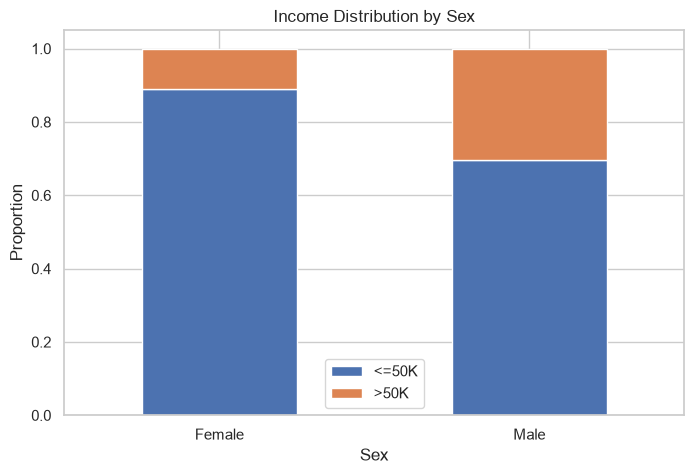

In [418]:
sex_income.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion")

plt.xticks(rotation=0)

plt.show()

In [419]:
race_income = pd.crosstab(
    df["race"],
    df["income_binary"],
    normalize="index"
)

race_income.columns = [
    "<=50K",
    ">50K"
]

display(race_income)

,<=50K,>50K
race,,
Amer-Indian-Eskimo,0.882979,0.117021
Asian-Pac-Islander,0.730744,0.269256
Black,0.879189,0.120811
Other,0.876847,0.123153
White,0.746013,0.253987


In [420]:
age_income = pd.crosstab(
    df["age_group"],
    df["income_binary"],
    normalize="index"
)

age_income.columns = [
    "<=50K",
    ">50K"
]

display(age_income)

,<=50K,>50K
age_group,,
18-24,0.988971,0.011029
25-34,0.831836,0.168164
35-44,0.667104,0.332896
45-54,0.606088,0.393912
55-64,0.678377,0.321623
65+,0.795400,0.204600


In [421]:
education_income = pd.crosstab(
    df["education"],
    df["income_binary"],
    normalize="index"
)

education_income.columns = [
    "<=50K",
    ">50K"
]

display(
    education_income
    .sort_values(
        ">50K",
        ascending=False
    )
)

,<=50K,>50K
education,,
Prof-school,0.260192,0.739808
Doctorate,0.274411,0.725589
Masters,0.450884,0.549116
Bachelors,0.587165,0.412835
Assoc-acdm,0.742036,0.257964
Assoc-voc,0.746725,0.253275
Some-college,0.810351,0.189649
HS-grad,0.841422,0.158578
12th,0.926941,0.073059


In [422]:
occupation_income = pd.crosstab(
    df["occupation"],
    df["income_binary"],
    normalize="index"
)

occupation_income.columns = [
    "<=50K",
    ">50K"
]

display(
    occupation_income
    .sort_values(
        ">50K",
        ascending=False
    )
)

,<=50K,>50K
occupation,,
Exec-managerial,0.522182,0.477818
Prof-specialty,0.548931,0.451069
Armed-Forces,0.666667,0.333333
Protective-serv,0.686673,0.313327
Tech-support,0.709544,0.290456
Sales,0.732013,0.267987
Craft-repair,0.773724,0.226276
Transport-moving,0.795754,0.204246
Adm-clerical,0.863126,0.136874


In [423]:
marital_income = pd.crosstab(
    df["marital-status"],
    df["income_binary"],
    normalize="index"
)

marital_income.columns = [
    "<=50K",
    ">50K"
]

display(marital_income)

,<=50K,>50K
marital-status,,
Divorced,0.898839,0.101161
Married-AF-spouse,0.621622,0.378378
Married-civ-spouse,0.553867,0.446133
Married-spouse-absent,0.907643,0.092357
Never-married,0.954520,0.045480
Separated,0.935294,0.064706
Widowed,0.915679,0.084321


In [424]:
relationship_income = pd.crosstab(
    df["relationship"],
    df["income_binary"],
    normalize="index"
)

relationship_income.columns = [
    "<=50K",
    ">50K"
]

display(relationship_income)

,<=50K,>50K
relationship,,
Husband,0.551329,0.448671
Not-in-family,0.898593,0.101407
Other-relative,0.965471,0.034529
Own-child,0.985358,0.014642
Unmarried,0.939707,0.060293
Wife,0.531103,0.468897


In [425]:
workclass_income = pd.crosstab(
    df["workclass"],
    df["income_binary"],
    normalize="index"
)

workclass_income.columns = [
    "<=50K",
    ">50K"
]

display(workclass_income)

,<=50K,>50K
workclass,,
?,0.895969,0.104031
Federal-gov,0.608240,0.391760
Local-gov,0.704401,0.295599
Never-worked,1.000000,0.000000
Private,0.782133,0.217867
Self-emp-inc,0.446608,0.553392
Self-emp-not-inc,0.721129,0.278871
State-gov,0.732458,0.267542
Without-pay,0.904762,0.095238


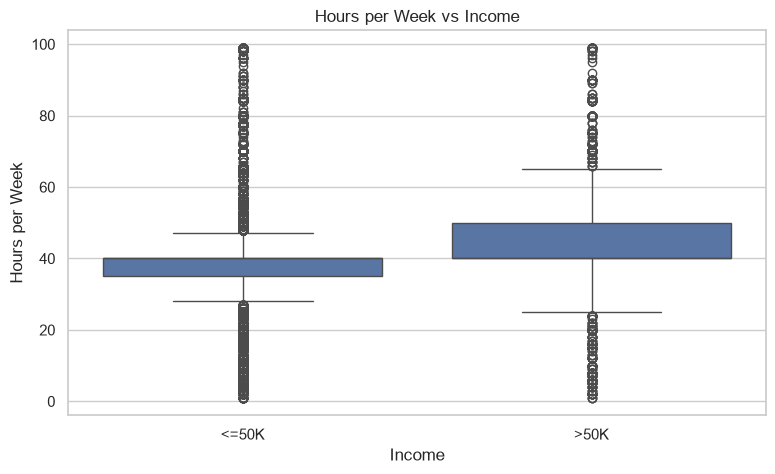

In [426]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Hours per Week vs Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

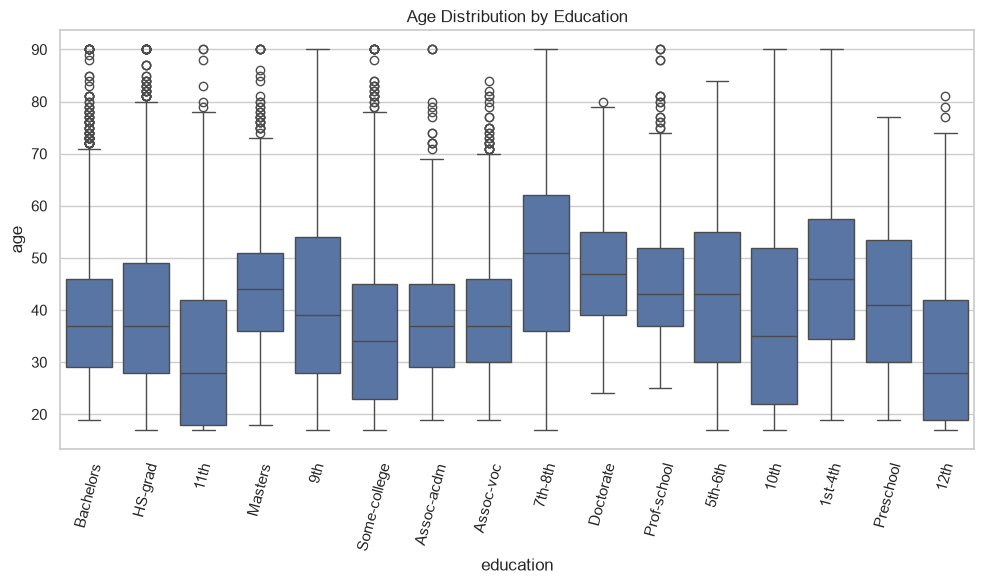

In [427]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="education",
    y="age"
)

plt.xticks(rotation=75)

plt.title("Age Distribution by Education")

plt.tight_layout()
plt.show()

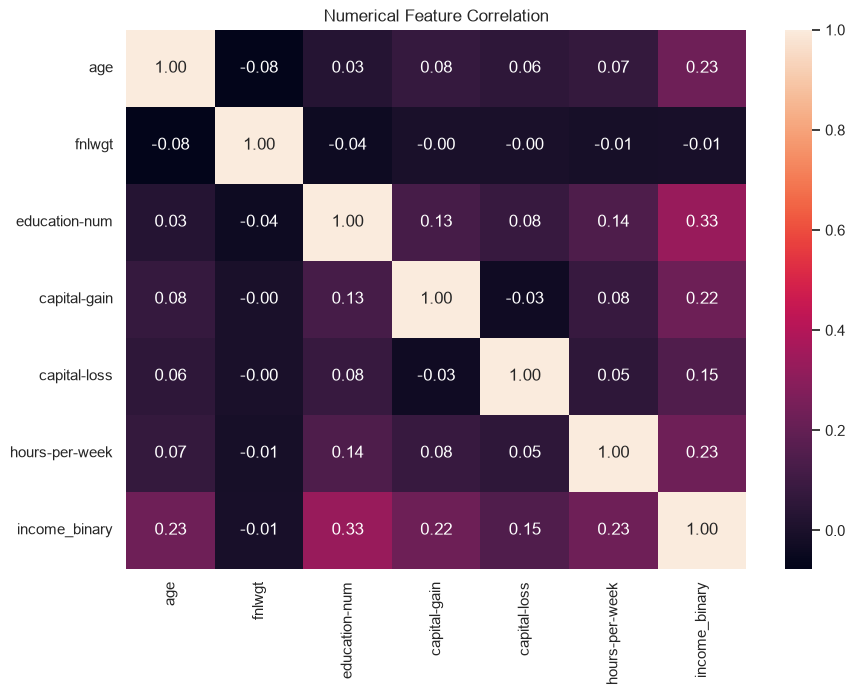

In [428]:
correlation_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "income_binary"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")

plt.show()

In [429]:
df["has_capital_gain"] = (
    df["capital-gain"] > 0
).astype(int)

df["has_capital_loss"] = (
    df["capital-loss"] > 0
).astype(int)

In [430]:
df["net_capital"] = (
    df["capital-gain"]
    - df["capital-loss"]
)

In [431]:
df["hours_category"] = pd.cut(
    df["hours-per-week"],
    bins=[
        0,
        20,
        40,
        60,
        np.inf
    ],
    labels=[
        "Low",
        "Normal",
        "High",
        "Very High"
    ]
)

display(
    df["hours_category"]
    .value_counts()
)

hours_category
Normal       30037
High         12676
Low           4453
Very High     1676
Name: count, dtype: int64

In [432]:
education_mapping = (
    df[
        ["education", "education-num"]
    ]
    .drop_duplicates()
    .sort_values("education-num")
)

display(education_mapping)

,education,education-num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


In [433]:
PROTECTED_ATTRIBUTES = [
    "sex",
    "race",
    "age_group"
]

print("Protected attributes for fairness analysis:")

for attribute in PROTECTED_ATTRIBUTES:
    print("-", attribute)

Protected attributes for fairness analysis:
- sex
- race
- age_group


In [434]:
TARGET = "income_binary"

print("Target:", TARGET)

Target: income_binary


In [435]:
# ==============================================================================
# CELL 48 — Final baseline feature set
# ==============================================================================
MODEL_FEATURES = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country"
]

X_model = df[MODEL_FEATURES].copy()
y_model = df[TARGET].copy()

print("X:", X_model.shape)
print("y:", y_model.shape)

X: (48842, 14)
y: (48842,)


In [436]:
# ==============================================================================
# CELL 49 — Check the final modelling dataset
# ==============================================================================
display(X_model.head())
display(y_model.head())
print("Missing values:")
display(X_model.isna().sum())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


0    0
1    0
2    0
3    0
4    0
Name: income_binary, dtype: int64

Missing values:


age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [437]:
# ==============================================================================
# CELL 50 — Fairness audit dataset
# ==============================================================================
sensitive_features = df[
    [
        "sex",
        "race",
        "age_group"
    ]
].copy()

display(sensitive_features.head())

,sex,race,age_group
0,Male,White,35-44
1,Male,White,45-54
2,Male,White,35-44
3,Male,Black,45-54
4,Female,Black,25-34


In [438]:
# ==============================================================================
# CELL 51 — Create intersectional attributes
# ==============================================================================
# Sex × Race
sensitive_features["sex_race"] = (
    sensitive_features["sex"].astype(str)
    + " | "
    + sensitive_features["race"].astype(str)
)

# Age × Sex
sensitive_features["age_sex"] = (
    sensitive_features["age_group"].astype(str)
    + " | "
    + sensitive_features["sex"].astype(str)
)

# Age × Race
sensitive_features["age_race"] = (
    sensitive_features["age_group"].astype(str)
    + " | "
    + sensitive_features["race"].astype(str)
)

# Age × Sex × Race
sensitive_features["age_sex_race"] = (
    sensitive_features["age_group"].astype(str)
    + " | "
    + sensitive_features["sex"].astype(str)
    + " | "
    + sensitive_features["race"].astype(str)
)

display(sensitive_features.head())

,sex,race,age_group,sex_race,age_sex,age_race,age_sex_race
0,Male,White,35-44,Male | White,35-44 | Male,35-44 | White,35-44 | Male | White
1,Male,White,45-54,Male | White,45-54 | Male,45-54 | White,45-54 | Male | White
2,Male,White,35-44,Male | White,35-44 | Male,35-44 | White,35-44 | Male | White
3,Male,Black,45-54,Male | Black,45-54 | Male,45-54 | Black,45-54 | Male | Black
4,Female,Black,25-34,Female | Black,25-34 | Female,25-34 | Black,25-34 | Female | Black


In [439]:
# ==============================================================================
# CELL 52 — Check subgroup sizes
# ==============================================================================
for column in sensitive_features.columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    display(
        sensitive_features[column]
        .value_counts()
        .to_frame("count")
    )


sex


,count
sex,
Male,32650
Female,16192



race


,count
race,
White,41762
Black,4685
Asian-Pac-Islander,1519
Amer-Indian-Eskimo,470
Other,406



age_group


...

,count
age_sex,
35-44 | Male,8647
25-34 | Male,8408
45-54 | Male,6214
18-24 | Male,4613
25-34 | Female,4169
18-24 | Female,3819
35-44 | Female,3546
55-64 | Male,3373
45-54 | Female,2557



age_race


,count
age_race,
25-34 | White,10486
35-44 | White,10374
45-54 | White,7572
18-24 | White,7253
55-64 | White,4192
65+ | White,1885
25-34 | Black,1346
35-44 | Black,1199
45-54 | Black,815



age_sex_race


,count
age_sex_race,
35-44 | Male | White,7638
25-34 | Male | White,7228
45-54 | Male | White,5542
18-24 | Male | White,4014
25-34 | Female | White,3258
18-24 | Female | White,3239
55-64 | Male | White,3036
35-44 | Female | White,2736
45-54 | Female | White,2030


In [440]:
# ==============================================================================
# CELL 53 — Save the processed EDA dataset
# ==============================================================================
df.to_csv(
    "adult_eda_processed.csv",
    index=False
)

print("Saved: adult_eda_processed.csv")

Saved: adult_eda_processed.csv


In [441]:
# Install necessary fairness and boosting libraries
!pip install fairlearn xgboost scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [442]:
# ==============================================================================
# 1. Data Cleaning & Feature Preprocessing (Leakage-Free)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Handle missing values: convert '?' markers to NaN
X_clean = X_model.copy()
X_clean.replace('?', np.nan, inplace=True)

# 2. Filter aligned valid records across features, target, and sensitive features
valid_idx = ~X_clean.isna().any(axis=1) & ~y_model.isna()
X_clean = X_clean[valid_idx].copy()
y_clean = y_model[valid_idx].astype(int).copy()
sensitive_clean = sensitive_features[valid_idx].copy()

# 3. Identify categorical and numerical columns
categorical_cols = X_clean.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

# 4. Encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_clean[col] = le.fit_transform(X_clean[col].astype(str))
    label_encoders[col] = le

# 5. Stratified Train-Test Split (aligning features, targets, and all sensitive attributes)
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X_clean, 
    y_clean,
    sensitive_clean,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_clean
)

# 6. Feature Scaling for numerical variables
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n[+] Data Cleaning & Preprocessing Complete.")
print(f"    Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"    Sensitive attributes tracked in audit stream: {list(sens_test.columns)}")

Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

[+] Data Cleaning & Preprocessing Complete.
    Train shape: (36177, 14) | Test shape: (9045, 14)
    Sensitive attributes tracked in audit stream: ['sex', 'race', 'age_group', 'sex_race', 'age_sex', 'age_race', 'age_sex_race']


In [443]:
# ==============================================================================
# 2. Model Training & Benchmark Comparison
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

best_model = None
best_accuracy = 0
best_model_name = ""

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    model_results.append({
        'Model': name, 
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}\n")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(model_results)
display(results_df)

print(f"\n--> Selected Best Model for Audit: {best_model_name} (Accuracy: {best_accuracy:.4f})")

--- Logistic Regression ---
Accuracy: 0.8200 | F1: 0.5545 | ROC-AUC: 0.8478

--- Random Forest ---
Accuracy: 0.8570 | F1: 0.6830 | ROC-AUC: 0.9072

--- XGBoost ---
Accuracy: 0.8674 | F1: 0.7071 | ROC-AUC: 0.9225



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8200,0.7174,0.4518,0.5545,0.8478
1,Random Forest,0.8570,0.7583,0.6213,0.6830,0.9072
2,XGBoost,0.8674,0.7817,0.6454,0.7071,0.9225



--> Selected Best Model for Audit: XGBoost (Accuracy: 0.8674)


In [444]:
# ==============================================================================
# 3. Comprehensive Fairness Audit Across ALL 7 Sensitive Attribute Combinations (Unmitigated)
# ==============================================================================
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    true_positive_rate,
    false_positive_rate
)

y_pred_best = best_model.predict(X_test)

# All 7 single, pairwise, and 3-way intersectional attribute combinations:
AUDIT_ATTRIBUTES = [
    "sex",
    "race",
    "age_group",
    "sex_race",
    "age_sex",
    "age_race",
    "age_sex_race"
]

fairness_summary_unmitigated = []

print("=" * 75)
print(f"FAIRNESS AUDIT FOR {best_model_name.upper()} (UNMITIGATED)")
print("=" * 75)

for attr in AUDIT_ATTRIBUTES:
    sens_col = sens_test[attr]
    dp_diff = demographic_parity_difference(y_test, y_pred_best, sensitive_features=sens_col)
    dp_ratio = demographic_parity_ratio(y_test, y_pred_best, sensitive_features=sens_col)
    eo_diff = equalized_odds_difference(y_test, y_pred_best, sensitive_features=sens_col)
    eo_ratio = equalized_odds_ratio(y_test, y_pred_best, sensitive_features=sens_col)
    
    fairness_summary_unmitigated.append({
        "Attribute Combination": attr,
        "Unique Subgroups": sens_col.nunique(),
        "Demographic Parity Diff": round(dp_diff, 4),
        "Demographic Parity Ratio": round(dp_ratio, 4),
        "Equalized Odds Diff": round(eo_diff, 4),
        "Equalized Odds Ratio": round(eo_ratio, 4)
    })
    
    # Detailed subgroup breakdown
    mf = MetricFrame(
        metrics={
            "Count": lambda y_t, y_p: len(y_t),
            "Selection Rate": selection_rate,
            "TPR (Recall)": true_positive_rate,
            "FPR": false_positive_rate,
            "Precision": precision_score,
            "Accuracy": accuracy_score
        },
        y_true=y_test,
        y_pred=y_pred_best,
        sensitive_features=sens_col
    )
    print(f"\n>>> Disaggregated Subgroup Metrics by [{attr.upper()}]:")
    display(mf.by_group.round(4))

df_fairness_unmitigated = pd.DataFrame(fairness_summary_unmitigated)
print("\n=== Summary Fairness Disparities Across ALL 7 Combinations (Unmitigated) ===")
display(df_fairness_unmitigated)

FAIRNESS AUDIT FOR XGBOOST (UNMITIGATED)

>>> Disaggregated Subgroup Metrics by [SEX]:


,Count,Selection Rate,TPR (Recall),FPR,Precision,Accuracy
sex,,,,,,
Female,2984.0,0.0885,0.5836,0.0220,0.7803,0.9313
Male,6061.0,0.2618,0.6570,0.0829,0.7820,0.8360



>>> Disaggregated Subgroup Metrics by [RACE]:


,Count,Selection Rate,TPR (Recall),FPR,Precision,Accuracy
race,,,,,,
Amer-Indian-Eskimo,96.0,0.0521,0.5000,0.0114,0.8000,0.9479
Asian-Pac-Islander,268.0,0.2575,0.6575,0.1077,0.6957,0.8284
Black,849.0,0.0777,0.4952,0.0188,0.7879,0.9211
Other,68.0,0.0588,0.4444,0.0000,1.0000,0.9265
White,7764.0,0.2199,0.6541,0.0644,0.7844,0.8614



>>> Disaggregated Subgroup Metrics by [AGE_GROUP]:


...

,Count,Selection Rate,TPR (Recall),FPR,Precision,Accuracy
age_race,,,,,,
18-24 | Amer-Indian-Eskimo,17.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Asian-Pac-Islander,44.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Black,141.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Other,15.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | White,1314.0,0.0015,0.0909,0.0000,1.0000,0.9848
25-34 | Amer-Indian-Eskimo,28.0,0.0357,0.3333,0.0000,1.0000,0.9286
25-34 | Asian-Pac-Islander,72.0,0.1389,0.4667,0.0526,0.7000,0.8472
25-34 | Black,266.0,0.0376,0.2857,0.0163,0.6000,0.9286
25-34 | Other,25.0,0.0400,0.5000,0.0000,1.0000,0.9600



>>> Disaggregated Subgroup Metrics by [AGE_SEX_RACE]:


,Count,Selection Rate,TPR (Recall),FPR,Precision,Accuracy
age_sex_race,,,,,,
18-24 | Female | Amer-Indian-Eskimo,7.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Female | Asian-Pac-Islander,20.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Female | Black,65.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Female | Other,5.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Female | White,581.0,0.0000,0.0000,0.0000,0.0000,0.9931
18-24 | Male | Amer-Indian-Eskimo,10.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Male | Asian-Pac-Islander,24.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Male | Black,76.0,0.0000,0.0000,0.0000,0.0000,1.0000
18-24 | Male | Other,10.0,0.0000,0.0000,0.0000,0.0000,1.0000



=== Summary Fairness Disparities Across ALL 7 Combinations (Unmitigated) ===


,Attribute Combination,Unique Subgroups,Demographic Parity Diff,Demographic Parity Ratio,Equalized Odds Diff,Equalized Odds Ratio
0,sex,2,0.1734,0.3379,0.0734,0.2658
1,race,5,0.2054,0.2023,0.2131,0.0000
2,age_group,6,0.3714,0.0035,0.6393,0.0000
3,sex_race,10,0.3371,0.0000,1.0000,0.0000
4,age_sex,12,0.4662,0.0000,0.7561,0.0000
5,age_race,28,0.4783,0.0000,1.0000,0.0000
6,age_sex_race,55,0.6875,0.0000,1.0000,0.0000


In [ ]:
# ==============================================================================
# 4. Bias Mitigation Across ALL 7 Combinations using Fairlearn (XGBoost Base Estimator)
# ==============================================================================
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from xgboost import XGBClassifier

# We train mitigated models targeting all 7 single and intersectional combinations using XGBoost:
# 1. Sex (Single)
# 2. Race (Single)
# 3. Age Group (Single)
# 4. Sex x Race (Pairwise)
# 5. Age x Sex (Pairwise)
# 6. Age x Race (Pairwise)
# 7. Age x Sex x Race (3-Way Full Intersection)

base_estimator = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

mitigators = {}
mitigated_preds = {}

mitigation_targets = {
    "sex": sens_train["sex"],
    "race": sens_train["race"],
    "age_group": sens_train["age_group"],
    "sex_race": sens_train["sex_race"],
    "age_sex": sens_train["age_sex"],
    "age_race": sens_train["age_race"],
    "age_sex_race": sens_train["age_sex_race"]
}

for attr_name, sens_train_col in mitigation_targets.items():
    print(f"[+] Training Fairlearn Mitigator (XGBoost) for [{attr_name}]...")
    mitigator = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=DemographicParity(),
        eps=0.01
    )
    mitigator.fit(X_train, y_train, sensitive_features=sens_train_col)
    mitigators[attr_name] = mitigator
    mitigated_preds[attr_name] = mitigator.predict(X_test)
    print(f"    --> Mitigated model (XGBoost) for [{attr_name}] trained successfully!")

print("\n[+] All 7 mitigated XGBoost models trained successfully!")

[+] Training Fairlearn Mitigator (XGBoost) for [sex]...
    --> Mitigated model (XGBoost) for [sex] trained successfully!
[+] Training Fairlearn Mitigator (XGBoost) for [race]...
    --> Mitigated model (XGBoost) for [race] trained successfully!
[+] Training Fairlearn Mitigator (XGBoost) for [age_group]...
    --> Mitigated model (XGBoost) for [age_group] trained successfully!
[+] Training Fairlearn Mitigator (XGBoost) for [sex_race]...
    --> Mitigated model (XGBoost) for [sex_race] trained successfully!
[+] Training Fairlearn Mitigator (XGBoost) for [age_sex]...
    --> Mitigated model (XGBoost) for [age_sex] trained successfully!
[+] Training Fairlearn Mitigator (XGBoost) for [age_race]...


     COMPREHENSIVE BEFORE vs AFTER FAIRNESS COMPARISON (ALL 7 COMBINATIONS)


,Attribute Combination,Unmitigated Acc,Mitigated Acc,Unmitigated DP Diff,Mitigated DP Diff,DP Reduction (%),Unmitigated EO Diff,Mitigated EO Diff,EO Reduction (%)
0,sex,0.8674,0.7400,0.1734,0.0061,96.5%,0.0734,0.0064,91.3%
1,race,0.8674,0.7400,0.2054,0.0517,74.8%,0.2131,0.0713,66.6%
2,age_group,0.8674,0.7400,0.3714,0.0234,93.7%,0.6393,0.0611,90.4%
3,sex_race,0.8674,0.7400,0.3371,0.0722,78.6%,1.0000,0.0900,91.0%
4,age_sex,0.8674,0.7400,0.4662,0.0251,94.6%,0.7561,0.0753,90.0%
5,age_race,0.8674,0.7400,0.4783,0.3333,30.3%,1.0000,0.5000,50.0%
6,age_sex_race,0.8674,0.7400,0.6875,0.3333,51.5%,1.0000,0.5000,50.0%



     DISAGGREGATED SUBGROUP BREAKDOWN FOR 3-WAY INTERSECTION (Age × Sex × Race)


,Sample Size,Selection Rate,TPR (Recall),FPR,Precision,Accuracy,Sample Status
age_sex_race,,,,,,,
35-44 | Male | White,1466.0,0.0362,0.0445,0.0306,0.4906,0.6010,Sufficient
25-34 | Male | White,1312.0,0.0305,0.0616,0.0216,0.4500,0.7744,Sufficient
45-54 | Male | White,1074.0,0.0531,0.0630,0.0431,0.5965,0.5074,Sufficient
18-24 | Male | White,733.0,0.0286,0.0000,0.0294,0.0000,0.9468,Sufficient
25-34 | Female | White,629.0,0.0334,0.0732,0.0274,0.2857,0.8553,Sufficient
55-64 | Male | White,586.0,0.0410,0.0426,0.0399,0.4167,0.5922,Sufficient
18-24 | Female | White,581.0,0.0258,0.0000,0.0260,0.0000,0.9673,Sufficient
35-44 | Female | White,543.0,0.0184,0.0357,0.0139,0.4000,0.7901,Sufficient
45-54 | Female | White,378.0,0.0503,0.0854,0.0405,0.3684,0.7698,Sufficient


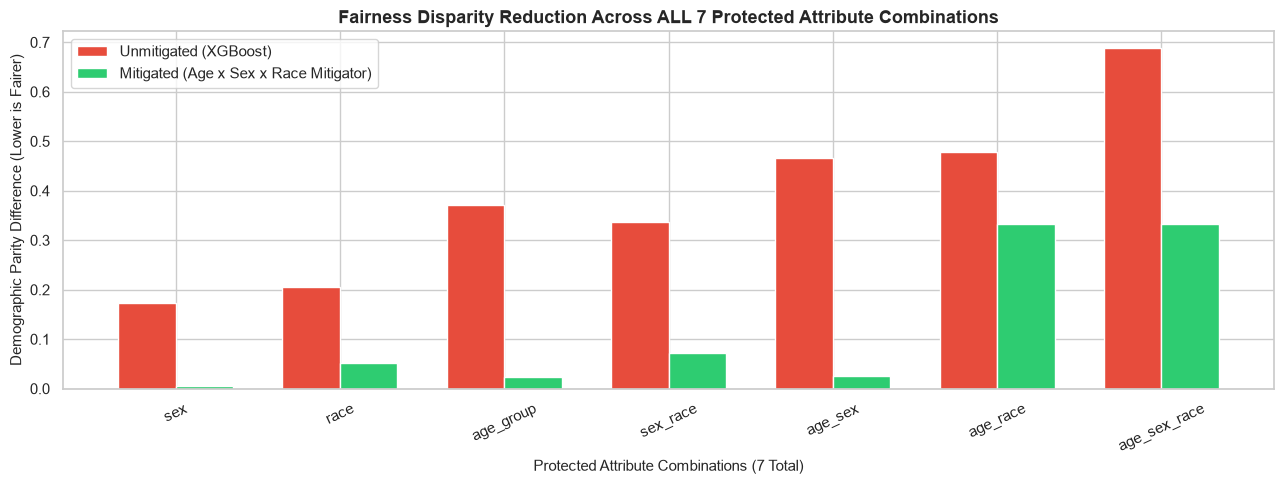

In [ ]:
# ==============================================================================
# 5. Fairness Evaluation & Comparison Across ALL 7 Combinations Post-Mitigation
# ==============================================================================
# Evaluate the full 3-way intersectional mitigator (age_sex_race) and pairwise mitigators
y_pred_mitigated_full = mitigated_preds["age_sex_race"]
y_pred_mitigated_sr = mitigated_preds["sex_race"]

comparison_records = []

for attr in AUDIT_ATTRIBUTES:
    sens_col = sens_test[attr]
    
    # Unmitigated metrics
    acc_unmit = accuracy_score(y_test, y_pred_best)
    dp_unmit = demographic_parity_difference(y_test, y_pred_best, sensitive_features=sens_col)
    eo_unmit = equalized_odds_difference(y_test, y_pred_best, sensitive_features=sens_col)
    
    # Mitigated metrics (under 3-way Age x Sex x Race mitigator)
    acc_mit = accuracy_score(y_test, y_pred_mitigated_full)
    dp_mit = demographic_parity_difference(y_test, y_pred_mitigated_full, sensitive_features=sens_col)
    eo_mit = equalized_odds_difference(y_test, y_pred_mitigated_full, sensitive_features=sens_col)
    
    # Disparity reductions (%)
    dp_reduction = ((dp_unmit - dp_mit) / dp_unmit * 100) if dp_unmit > 0 else 0.0
    eo_reduction = ((eo_unmit - eo_mit) / eo_unmit * 100) if eo_unmit > 0 else 0.0
    
    comparison_records.append({
        "Attribute Combination": attr,
        "Unmitigated Acc": f"{acc_unmit:.4f}",
        "Mitigated Acc": f"{acc_mit:.4f}",
        "Unmitigated DP Diff": f"{dp_unmit:.4f}",
        "Mitigated DP Diff": f"{dp_mit:.4f}",
        "DP Reduction (%)": f"{dp_reduction:.1f}%",
        "Unmitigated EO Diff": f"{eo_unmit:.4f}",
        "Mitigated EO Diff": f"{eo_mit:.4f}",
        "EO Reduction (%)": f"{eo_reduction:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_records)

print("=" * 95)
print("     COMPREHENSIVE BEFORE vs AFTER FAIRNESS COMPARISON (ALL 7 COMBINATIONS)")
print("=" * 95)
display(comparison_df)

# ==============================================================================
# Detailed Disaggregated Subgroup Report for 3-Way Intersection (Age x Sex x Race)
# ==============================================================================
print("\n" + "=" * 95)
print("     DISAGGREGATED SUBGROUP BREAKDOWN FOR 3-WAY INTERSECTION (Age × Sex × Race)")
print("=" * 95)

mf_age_sex_race = MetricFrame(
    metrics={
        "Sample Size": lambda y_t, y_p: len(y_t),
        "Selection Rate": selection_rate,
        "TPR (Recall)": true_positive_rate,
        "FPR": false_positive_rate,
        "Precision": precision_score,
        "Accuracy": accuracy_score
    },
    y_true=y_test,
    y_pred=y_pred_mitigated_full,
    sensitive_features=sens_test["age_sex_race"]
)

subgroup_df = mf_age_sex_race.by_group.round(4).copy()
subgroup_df["Sample Status"] = np.where(subgroup_df["Sample Size"] < 30, "Low Sample (<30)", "Sufficient")
subgroup_df = subgroup_df.sort_values("Sample Size", ascending=False)

display(subgroup_df)

# Visualizing Demographic Parity Difference across all 7 combinations
plt.figure(figsize=(13, 5))
x = np.arange(len(AUDIT_ATTRIBUTES))
width = 0.35

dp_unmit_vals = [demographic_parity_difference(y_test, y_pred_best, sensitive_features=sens_test[a]) for a in AUDIT_ATTRIBUTES]
dp_mit_vals = [demographic_parity_difference(y_test, y_pred_mitigated_full, sensitive_features=sens_test[a]) for a in AUDIT_ATTRIBUTES]

plt.bar(x - width/2, dp_unmit_vals, width, label=f'Unmitigated ({best_model_name})', color='#e74c3c')
plt.bar(x + width/2, dp_mit_vals, width, label='Mitigated (Age x Sex x Race Mitigator)', color='#2ecc71')

plt.xlabel('Protected Attribute Combinations (7 Total)', fontsize=11)
plt.ylabel('Demographic Parity Difference (Lower is Fairer)', fontsize=11)
plt.title('Fairness Disparity Reduction Across ALL 7 Protected Attribute Combinations', fontsize=13, fontweight='bold')
plt.xticks(x, AUDIT_ATTRIBUTES, rotation=25)
plt.legend()
plt.tight_layout()
plt.show()